# Smíšený PINN pro 2D lineární elastostatiku

Cílem je současně aproximovat dvě složky posunutí a tři složky symetrického tenzoru napětí na oblasti

$$
\Omega=(0,1)^2.
$$

Síť má pět fyzikálních výstupů

$$
\mathbf q_\theta(x,y)
=
\begin{bmatrix}
u_{1,\theta} & u_{2,\theta} &
\sigma_{xx,\theta} & \sigma_{yy,\theta} & \sigma_{xy,\theta}
\end{bmatrix}^{\mathsf T}.
$$
Přesné řešení posunutí bylo zvoleno jako

$$
\mathbf u_{\mathrm{exact}}(x,y)
=
a
\begin{bmatrix}
\cos x-y^2\\
2\sin x+y
\end{bmatrix},
\qquad a=0.005.
$$

Materiálové parametry jsou

$$
E=1,
\qquad
\nu=\frac14,
\qquad
\lambda=\mu=\frac25.
$$

## Silná forma

Tenzor malých deformací je

$$
\boldsymbol\varepsilon(\mathbf u)
=
\frac12\left(\nabla\mathbf u+\nabla\mathbf u^{\mathsf T}\right),
$$

a konstitutivní vztah má tvar

$$
\boldsymbol\sigma
=
\lambda\operatorname{tr}(\boldsymbol\varepsilon)\mathbf I
+2\mu\boldsymbol\varepsilon.
$$

Rovnice rovnováhy je

$$
\nabla\cdot\boldsymbol\sigma+\mathbf b=\mathbf0
\qquad\text{v }\Omega.
$$

Pro zvolené přesné řešení vychází

$$
\boldsymbol\varepsilon
=
\begin{bmatrix}
-a\sin x & a(\cos x-y)\\
a(\cos x-y) & a
\end{bmatrix},
$$

$$
\operatorname{tr}(\boldsymbol\varepsilon)
=a(1-\sin x),
$$

a při $\lambda=\mu=2/5$

$$
\boldsymbol\sigma_{\mathrm{exact}}(x,y)
=
\begin{bmatrix}
\dfrac{2a}{5}(1-3\sin x) & \dfrac{4a}{5}(\cos x-y)\\[0.6em]
\dfrac{4a}{5}(\cos x-y) & \dfrac{2a}{5}(3-\sin x)
\end{bmatrix}.
$$

Objemová síla, která zajišťuje rovnováhu přesného řešení, je

$$
\mathbf b(x,y)
=
\begin{bmatrix}
\dfrac{6a}{5}\cos x+\dfrac{4a}{5}\\[0.6em]
\dfrac{4a}{5}\sin x
\end{bmatrix}.
$$

## Smíšené okrajové podmínky

Na levé a pravé hraně předepisujeme přesné posunutí. Na dolní a horní hraně předepisujeme přesnou trakci $\mathbf t=\boldsymbol\sigma\mathbf n$.

Na $x=0$ platí

$$
\mathbf u(0,y)
=a
\begin{bmatrix}
1-y^2\\y
\end{bmatrix},
$$

a na $x=1$

$$
\mathbf u(1,y)
=a
\begin{bmatrix}
\cos1-y^2\\2\sin1+y
\end{bmatrix}.
$$

Na horní hraně $y=1$, kde $\mathbf n=(0,1)^{\mathsf T}$, je

$$
\mathbf t_{\mathrm{top}}(x)
=
\begin{bmatrix}
\dfrac{4a}{5}(\cos x-1)\\[0.6em]
\dfrac{2a}{5}(3-\sin x)
\end{bmatrix}.
$$

Na dolní hraně $y=0$, kde $\mathbf n=(0,-1)^{\mathsf T}$, je

$$
\mathbf t_{\mathrm{bottom}}(x)
=
\begin{bmatrix}
-\dfrac{4a}{5}\cos x\\[0.6em]
-\dfrac{2a}{5}(3-\sin x)
\end{bmatrix}.
$$


## 1. Import knihoven


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


## 2. Nastavení parametrů

- `USE_DATA = False`: čistý smíšený PINN.
- `USE_DATA = True`: přidá se loss známých hodnot všech pěti polí.
- Prvních 1900 epoch používá Adam a posledních 100 epoch L-BFGS.

In [9]:
USE_DATA = True

E = 1.0
NU = 1.0 / 4.0
LAMBDA = 2.0 / 5.0
MU = 2.0 / 5.0
AMPLITUDE = 0.005

N_PDE_TRAIN = 2000
N_PDE_TEST = 2000
N_BOUNDARY_PER_EDGE = 100
N_DATA_TRAIN = 200
N_DATA_TEST = 200

EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)

E_FROM_LAME = MU * (3.0 * LAMBDA + 2.0 * MU) / (LAMBDA + MU)
NU_FROM_LAME = LAMBDA / (2.0 * (LAMBDA + MU))

print(f"E z Lameho konstant:  {E_FROM_LAME:.6f}")
print(f"nu z Lameho konstant: {NU_FROM_LAME:.6f}")


E z Lameho konstant:  1.000000
nu z Lameho konstant: 0.250000


## 3. Přesné posunutí, napětí, objemová síla a trakce


In [10]:
def exact_displacement(xy):
    """Presne posunuti [u1, u2]."""
    x = xy[:, 0:1]
    y = xy[:, 1:2]

    u1 = AMPLITUDE * (torch.cos(x) - y**2)
    u2 = AMPLITUDE * (2.0 * torch.sin(x) + y)
    return torch.cat((u1, u2), dim=1)


def exact_stress(xy):
    """Presne slozky [sigma_xx, sigma_yy, sigma_xy]."""
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    a = AMPLITUDE

    eps_xx = -a * torch.sin(x)
    eps_yy = a * torch.ones_like(x)
    eps_xy = a * (torch.cos(x) - y)
    trace_eps = eps_xx + eps_yy

    sigma_xx = LAMBDA * trace_eps + 2.0 * MU * eps_xx
    sigma_yy = LAMBDA * trace_eps + 2.0 * MU * eps_yy
    sigma_xy = 2.0 * MU * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)


def exact_fields(xy):
    """Vsech pet presnych poli [u1, u2, sxx, syy, sxy]."""
    return torch.cat((exact_displacement(xy), exact_stress(xy)), dim=1)


def body_force(xy):
    """b = -div(sigma_exact)."""
    x = xy[:, 0:1]
    a = AMPLITUDE

    b1 = a * (LAMBDA + 2.0 * MU) * torch.cos(x) + 2.0 * MU * a
    b2 = 2.0 * MU * a * torch.sin(x)
    return torch.cat((b1, b2), dim=1)


def exact_traction(xy, normals):
    """Presna trakce t = sigma_exact*n."""
    stress = exact_stress(xy)
    sigma_xx = stress[:, 0:1]
    sigma_yy = stress[:, 1:2]
    sigma_xy = stress[:, 2:3]

    nx = normals[:, 0:1]
    ny = normals[:, 1:2]

    traction_x = sigma_xx * nx + sigma_xy * ny
    traction_y = sigma_xy * nx + sigma_yy * ny
    return torch.cat((traction_x, traction_y), dim=1)


## 4. Neuronová síť s pěti výstupy

Výstupy sítě mají pořadí

$$
[u_{1,\theta},u_{2,\theta},\sigma_{xx,\theta},
\sigma_{yy,\theta},\sigma_{xy,\theta}].
$$


In [11]:
class MixedPINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 5),
        )

    def forward(self, xy):
        return self.net(xy)


model = MixedPINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Trénovací, testovací a okrajové body

- `xy_pde_train`: kolokační body.
- `xy_pde_test`: testovací body.
- `xy_dirichlet`: body na hranách $x=0$ a $x=1$.
- `xy_neumann`: body na hranách $y=0$ a $y=1$.


In [12]:
pde_train_generator = torch.Generator().manual_seed(SEED + 1)
xy_pde_train = torch.rand(
    N_PDE_TRAIN,
    2,
    generator=pde_train_generator,
)
xy_pde_train.requires_grad_(True)

pde_test_generator = torch.Generator().manual_seed(SEED + 2)
xy_pde_test = torch.rand(
    N_PDE_TEST,
    2,
    generator=pde_test_generator,
)
xy_pde_test.requires_grad_(True)

t = torch.linspace(0.0, 1.0, N_BOUNDARY_PER_EDGE).view(-1, 1)

# Dirichletovy body na x=0 a x=1.
left = torch.cat((torch.zeros_like(t), t), dim=1)
right = torch.cat((torch.ones_like(t), t), dim=1)
xy_dirichlet = torch.cat((left, right), dim=0)
u_dirichlet = exact_displacement(xy_dirichlet)

# Neumannovy body na y=0 a y=1.
bottom = torch.cat((t, torch.zeros_like(t)), dim=1)
top = torch.cat((t, torch.ones_like(t)), dim=1)

normal_bottom = torch.cat(
    (torch.zeros_like(t), -torch.ones_like(t)),
    dim=1,
)
normal_top = torch.cat(
    (torch.zeros_like(t), torch.ones_like(t)),
    dim=1,
)

xy_neumann = torch.cat((bottom, top), dim=0)
normals_neumann = torch.cat((normal_bottom, normal_top), dim=0)
traction_neumann = exact_traction(xy_neumann, normals_neumann)

if USE_DATA:
    data_train_generator = torch.Generator().manual_seed(SEED + 3)
    xy_data_train = torch.rand(
        N_DATA_TRAIN,
        2,
        generator=data_train_generator,
    )
    fields_data_train = exact_fields(xy_data_train)

    data_test_generator = torch.Generator().manual_seed(SEED + 4)
    xy_data_test = torch.rand(
        N_DATA_TEST,
        2,
        generator=data_test_generator,
    )
    fields_data_test = exact_fields(xy_data_test)


## 6. Rovnovážné a konstitutivní reziduum

Protože síť predikuje napětí samostatně, fyzikální loss obsahuje dvě části.

Rovnovážné reziduum je

$$
\mathbf r_{\mathrm{eq},\theta}
=
\nabla\cdot\boldsymbol\sigma_\theta+\mathbf b.
$$

Konstitutivní reziduum spojuje predikované napětí s predikovaným posunutím:

$$
\mathbf r_{\mathrm{const},\theta}
=
\boldsymbol\sigma_\theta
-
\left[
\lambda\operatorname{tr}(\boldsymbol\varepsilon(\mathbf u_\theta))\mathbf I
+2\mu\boldsymbol\varepsilon(\mathbf u_\theta)
\right].
$$

Celková loss je

$$
\mathcal L
=
\mathcal L_{\mathrm{eq}}
+\mathcal L_{\mathrm{const}}
+\mathcal L_{\mathrm D}
+\mathcal L_{\mathrm N}
+\mathcal L_{\mathrm{data}}.
$$

Pro `USE_DATA = False` je $\mathcal L_{\mathrm{data}}=0$.


In [13]:
def split_prediction(prediction):
    u1 = prediction[:, 0:1]
    u2 = prediction[:, 1:2]
    sigma_xx = prediction[:, 2:3]
    sigma_yy = prediction[:, 3:4]
    sigma_xy = prediction[:, 4:5]
    return u1, u2, sigma_xx, sigma_yy, sigma_xy


def constitutive_stress_from_displacement(
    xy,
    u1,
    u2,
    create_graph,
):
    grad_u1 = torch.autograd.grad(
        u1,
        xy,
        grad_outputs=torch.ones_like(u1),
        create_graph=create_graph,
        retain_graph=True,
    )[0]
    grad_u2 = torch.autograd.grad(
        u2,
        xy,
        grad_outputs=torch.ones_like(u2),
        create_graph=create_graph,
        retain_graph=True,
    )[0]

    eps_xx = grad_u1[:, 0:1]
    eps_yy = grad_u2[:, 1:2]
    eps_xy = 0.5 * (grad_u1[:, 1:2] + grad_u2[:, 0:1])
    trace_eps = eps_xx + eps_yy

    sigma_xx = LAMBDA * trace_eps + 2.0 * MU * eps_xx
    sigma_yy = LAMBDA * trace_eps + 2.0 * MU * eps_yy
    sigma_xy = 2.0 * MU * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)


def mixed_residuals(xy, training=True):
    prediction = model(xy)
    u1, u2, sigma_xx, sigma_yy, sigma_xy = split_prediction(prediction)

    constitutive_stress = constitutive_stress_from_displacement(
        xy,
        u1,
        u2,
        create_graph=training,
    )
    predicted_stress = torch.cat(
        (sigma_xx, sigma_yy, sigma_xy),
        dim=1,
    )
    residual_constitutive = predicted_stress - constitutive_stress

    grad_sigma_xx = torch.autograd.grad(
        sigma_xx,
        xy,
        grad_outputs=torch.ones_like(sigma_xx),
        create_graph=training,
        retain_graph=True,
    )[0]
    grad_sigma_yy = torch.autograd.grad(
        sigma_yy,
        xy,
        grad_outputs=torch.ones_like(sigma_yy),
        create_graph=training,
        retain_graph=True,
    )[0]
    grad_sigma_xy = torch.autograd.grad(
        sigma_xy,
        xy,
        grad_outputs=torch.ones_like(sigma_xy),
        create_graph=training,
        retain_graph=True,
    )[0]

    b = body_force(xy)
    residual_1 = (
        grad_sigma_xx[:, 0:1]
        + grad_sigma_xy[:, 1:2]
        + b[:, 0:1]
    )
    residual_2 = (
        grad_sigma_xy[:, 0:1]
        + grad_sigma_yy[:, 1:2]
        + b[:, 1:2]
    )
    residual_equilibrium = torch.cat((residual_1, residual_2), dim=1)

    return residual_equilibrium, residual_constitutive, prediction


def compute_losses():
    residual_eq, residual_const, _ = mixed_residuals(
        xy_pde_train,
        training=True,
    )
    loss_equilibrium = torch.mean(residual_eq**2)
    loss_constitutive = torch.mean(residual_const**2)

    dirichlet_prediction = model(xy_dirichlet)[:, 0:2]
    loss_dirichlet = torch.mean(
        (dirichlet_prediction - u_dirichlet) ** 2
    )

    neumann_prediction = model(xy_neumann)
    _, _, sigma_xx, sigma_yy, sigma_xy = split_prediction(
        neumann_prediction
    )
    nx = normals_neumann[:, 0:1]
    ny = normals_neumann[:, 1:2]
    traction_x = sigma_xx * nx + sigma_xy * ny
    traction_y = sigma_xy * nx + sigma_yy * ny
    traction_prediction = torch.cat((traction_x, traction_y), dim=1)
    loss_neumann = torch.mean(
        (traction_prediction - traction_neumann) ** 2
    )
    loss_boundary = loss_dirichlet + loss_neumann

    if USE_DATA:
        data_prediction = model(xy_data_train)
        loss_data = torch.mean(
            (data_prediction - fields_data_train) ** 2
        )
    else:
        loss_data = torch.tensor(0.0)

    loss = (
        loss_equilibrium
        + loss_constitutive
        + loss_boundary
        + loss_data
    )

    return (
        loss,
        loss_equilibrium,
        loss_constitutive,
        loss_boundary,
        loss_data,
    )


## 7. Trénování: Adam a L-BFGS

Prvních 1900 epoch používá Adam. Posledních 100 epoch používá L-BFGS s funkcí `closure`.


In [14]:
loss_history = []
equilibrium_loss_history = []
constitutive_loss_history = []
boundary_loss_history = []
data_loss_history = []

ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_adam,
    mode="min",
    factor=0.5,
    patience=200,
)

for epoch in range(ADAM_EPOCHS):
    optimizer_adam.zero_grad()
    xy_pde_train.grad = None

    losses = compute_losses()
    loss, loss_eq, loss_const, loss_bc, loss_data = losses
    loss.backward()
    optimizer_adam.step()
    scheduler.step(loss.item())

    loss_history.append(loss.detach().item())
    equilibrium_loss_history.append(loss_eq.detach().item())
    constitutive_loss_history.append(loss_const.detach().item())
    boundary_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())

    if epoch % 500 == 0:
        print(
            f"Adam | epocha {epoch:5d} | loss={loss.item():.6e} | "
            f"eq={loss_eq.item():.6e} | const={loss_const.item():.6e} | "
            f"BC={loss_bc.item():.6e} | data={loss_data.item():.6e}"
        )

print(f"Prepinam z Adam na L-BFGS v epose {ADAM_EPOCHS}.")

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe",
)

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad()
        xy_pde_train.grad = None
        loss, _, _, _, _ = compute_losses()
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)

    losses = compute_losses()
    loss, loss_eq, loss_const, loss_bc, loss_data = losses

    loss_history.append(loss.detach().item())
    equilibrium_loss_history.append(loss_eq.detach().item())
    constitutive_loss_history.append(loss_const.detach().item())
    boundary_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())

    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(
            f"L-BFGS | epocha {epoch:5d} | loss={loss.item():.6e} | "
            f"eq={loss_eq.item():.6e} | const={loss_const.item():.6e} | "
            f"BC={loss_bc.item():.6e} | data={loss_data.item():.6e}"
        )

model.eval()


Adam | epocha     0 | loss=1.261162e-01 | eq=3.361859e-04 | const=3.691188e-02 | BC=6.329291e-02 | data=2.557526e-02
Adam | epocha   500 | loss=4.552885e-06 | eq=2.202272e-06 | const=1.579675e-06 | BC=5.644668e-07 | data=2.064706e-07
Adam | epocha  1000 | loss=2.124505e-06 | eq=5.815223e-07 | const=9.734758e-07 | BC=4.120491e-07 | data=1.574579e-07
Adam | epocha  1500 | loss=1.406598e-06 | eq=3.321900e-07 | const=6.467999e-07 | BC=3.036555e-07 | data=1.239527e-07
Prepinam z Adam na L-BFGS v epose 1900.
L-BFGS | epocha  1900 | loss=1.066853e-06 | eq=2.666134e-07 | const=4.693566e-07 | BC=2.310517e-07 | data=9.983117e-08
L-BFGS | epocha  1950 | loss=1.066853e-06 | eq=2.666134e-07 | const=4.693566e-07 | BC=2.310517e-07 | data=9.983117e-08
L-BFGS | epocha  1999 | loss=1.066853e-06 | eq=2.666134e-07 | const=4.693566e-07 | BC=2.310517e-07 | data=9.983117e-08


MixedPINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): Tanh()
    (6): Linear(in_features=20, out_features=20, bias=True)
    (7): Tanh()
    (8): Linear(in_features=20, out_features=20, bias=True)
    (9): Tanh()
    (10): Linear(in_features=20, out_features=5, bias=True)
  )
)

## 8. Testování na nezávislých bodech

Vyhodnotíme samostatně posunutí a napětí:

- $R^2$ a relativní $L^2$ chybu posunutí,
- $R^2$ a relativní $L^2$ chybu napětí,
- MSE rovnovážného rezidua,
- MSE konstitutivního rezidua.


In [15]:
model.eval()
xy_pde_test.grad = None

residual_eq_test, residual_const_test, prediction_test = mixed_residuals(
    xy_pde_test,
    training=False,
)

prediction_test = prediction_test.detach()
exact_test = exact_fields(xy_pde_test).detach()

u_prediction = prediction_test[:, 0:2]
u_exact = exact_test[:, 0:2]
stress_prediction = prediction_test[:, 2:5]
stress_exact = exact_test[:, 2:5]


def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact) ** 2)
    ss_tot = torch.sum((exact - torch.mean(exact)) ** 2)
    return (1.0 - ss_res / ss_tot).item()


def relative_l2(prediction, exact):
    return (
        torch.linalg.vector_norm(prediction - exact)
        / torch.linalg.vector_norm(exact)
    ).item()


r2_u = r2_score(u_prediction, u_exact)
relative_l2_u = relative_l2(u_prediction, u_exact)
r2_stress = r2_score(stress_prediction, stress_exact)
relative_l2_stress = relative_l2(stress_prediction, stress_exact)
equilibrium_mse = torch.mean(residual_eq_test**2).detach().item()
constitutive_mse = torch.mean(residual_const_test**2).detach().item()

metrics = {
    "R2_displacement": r2_u,
    "relative_L2_displacement": relative_l2_u,
    "R2_stress": r2_stress,
    "relative_L2_stress": relative_l2_stress,
    "equilibrium_residual_MSE": equilibrium_mse,
    "constitutive_residual_MSE": constitutive_mse,
}

print("=" * 66)
print("TESTOVACI VYSLEDKY SMISENEHO 2D PINN")
print("=" * 66)
print(f"R2 posunuti:                     {r2_u:.8f}")
print(f"Relativni L2 chyba posunuti:     {relative_l2_u:.6e}")
print(f"R2 napeti:                       {r2_stress:.8f}")
print(f"Relativni L2 chyba napeti:       {relative_l2_stress:.6e}")
print(f"MSE rovnovazneho rezidua:        {equilibrium_mse:.6e}")
print(f"MSE konstitutivniho rezidua:     {constitutive_mse:.6e}")
print("=" * 66)

metrics


TESTOVACI VYSLEDKY SMISENEHO 2D PINN
R2 posunuti:                     0.99189454
Relativni L2 chyba posunuti:     5.064776e-02
R2 napeti:                       0.98540914
Relativni L2 chyba napeti:       9.925523e-02
MSE rovnovazneho rezidua:        2.812659e-07
MSE konstitutivniho rezidua:     4.835586e-07


{'R2_displacement': 0.991894543170929,
 'relative_L2_displacement': 0.050647761672735214,
 'R2_stress': 0.985409140586853,
 'relative_L2_stress': 0.09925522655248642,
 'equilibrium_residual_MSE': 2.812658692619152e-07,
 'constitutive_residual_MSE': 4.835586082663212e-07}

## 9. Vizualizační funkce


In [16]:
def make_grid(n=101, requires_grad=False):
    values = torch.linspace(0.0, 1.0, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)

    if requires_grad:
        xy.requires_grad_(True)

    return X.numpy(), Y.numpy(), xy


def plot_points():
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(
        xy_pde_test[:, 0].detach().numpy(),
        xy_pde_test[:, 1].detach().numpy(),
        s=8,
        alpha=0.25,
        label="PDE test",
    )
    ax.scatter(
        xy_pde_train[:, 0].detach().numpy(),
        xy_pde_train[:, 1].detach().numpy(),
        s=10,
        alpha=0.5,
        label="PDE train",
    )
    ax.scatter(
        xy_dirichlet[:, 0].numpy(),
        xy_dirichlet[:, 1].numpy(),
        s=14,
        color="tab:red",
        label="Dirichlet",
    )
    ax.scatter(
        xy_neumann[:, 0].numpy(),
        xy_neumann[:, 1].numpy(),
        s=14,
        color="black",
        label="Neumann",
    )
    ax.set(title="Trenovaci, testovaci a okrajove body", xlabel="x", ylabel="y")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    plt.show()


def plot_field_comparison(field_indices, names, filename, n=101):
    X, Y, xy = make_grid(n)

    with torch.no_grad():
        prediction = model(xy).numpy().reshape(n, n, 5)
        exact = exact_fields(xy).numpy().reshape(n, n, 5)

    error = np.abs(prediction - exact)
    nrows = len(field_indices)
    fig, axes = plt.subplots(nrows, 3, figsize=(15, 4.2 * nrows))

    if nrows == 1:
        axes = axes.reshape(1, 3)

    for row, (field_index, name) in enumerate(zip(field_indices, names)):
        limit = max(
            np.max(np.abs(exact[:, :, field_index])),
            np.max(np.abs(prediction[:, :, field_index])),
        )

        images = [
            axes[row, 0].contourf(
                X, Y, exact[:, :, field_index], levels=40,
                cmap="coolwarm", vmin=-limit, vmax=limit,
            ),
            axes[row, 1].contourf(
                X, Y, prediction[:, :, field_index], levels=40,
                cmap="coolwarm", vmin=-limit, vmax=limit,
            ),
            axes[row, 2].contourf(
                X, Y, error[:, :, field_index], levels=40,
                cmap="viridis",
            ),
        ]

        axes[row, 0].set_title(f"Presne {name}")
        axes[row, 1].set_title(f"PINN {name}")
        axes[row, 2].set_title(f"Absolutni chyba {name}")

        for axis, image in zip(axes[row], images):
            axis.set(xlabel="x", ylabel="y")
            axis.set_aspect("equal")
            fig.colorbar(image, ax=axis)

    fig.tight_layout()
    #plt.savefig(filename, bbox_inches="tight")
    plt.show()


def plot_displacement(n=101):
    plot_field_comparison(
        field_indices=[0, 1],
        names=["u1", "u2"],
        filename="mixed_pinn_displacement.pdf",
        n=n,
    )


def plot_stress(n=101):
    plot_field_comparison(
        field_indices=[2, 3, 4],
        names=["sigma_xx", "sigma_yy", "sigma_xy"],
        filename="mixed_pinn_stress.pdf",
        n=n,
    )


def plot_deformed_domain(scale=1.0, n_lines=11, n_points=101):
    fig, ax = plt.subplots(figsize=(8, 8))
    coordinates = torch.linspace(0.0, 1.0, n_points)
    line_values = torch.linspace(0.0, 1.0, n_lines)
    first_line = True

    for value in line_values:
        horizontal = torch.stack(
            (coordinates, value * torch.ones_like(coordinates)), dim=1
        )
        vertical = torch.stack(
            (value * torch.ones_like(coordinates), coordinates), dim=1
        )

        for line in (horizontal, vertical):
            with torch.no_grad():
                exact_deformed = line + scale * exact_displacement(line)
                pinn_deformed = line + scale * model(line)[:, 0:2]

            ax.plot(
                line[:, 0].numpy(), line[:, 1].numpy(),
                color="gray", linestyle=":", alpha=0.4,
                label="puvodni" if first_line else None,
            )
            ax.plot(
                exact_deformed[:, 0].numpy(), exact_deformed[:, 1].numpy(),
                "r--", alpha=0.8,
                label="presna deformace" if first_line else None,
            )
            ax.plot(
                pinn_deformed[:, 0].numpy(), pinn_deformed[:, 1].numpy(),
                color="tab:blue", alpha=0.8,
                label="PINN deformace" if first_line else None,
            )
            first_line = False

    ax.set(
        title=f"Deformovana oblast, meritko posunuti = {scale}",
        xlabel="x", ylabel="y",
    )
    ax.set_aspect("equal")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    #plt.savefig("mixed_pinn_deformed.pdf", bbox_inches="tight")
    plt.show()


def plot_residuals(n=101):
    X, Y, xy = make_grid(n, requires_grad=True)
    residual_eq, residual_const, _ = mixed_residuals(xy, training=False)
    residual_eq = residual_eq.detach().numpy().reshape(n, n, 2)
    residual_const = residual_const.detach().numpy().reshape(n, n, 3)

    names = ["r_eq_1", "r_eq_2", "r_const_xx", "r_const_yy", "r_const_xy"]
    values = [
        residual_eq[:, :, 0],
        residual_eq[:, :, 1],
        residual_const[:, :, 0],
        residual_const[:, :, 1],
        residual_const[:, :, 2],
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()

    for axis, name, value in zip(axes, names, values):
        image = axis.contourf(X, Y, value, levels=40, cmap="coolwarm")
        axis.set(title=name, xlabel="x", ylabel="y")
        axis.set_aspect("equal")
        fig.colorbar(image, ax=axis)

    axes[-1].axis("off")
    fig.tight_layout()
    #plt.savefig("mixed_pinn_residuals.pdf", bbox_inches="tight")
    plt.show()


def plot_loss():
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(loss_history, label="celkova")
    ax.plot(equilibrium_loss_history, label="rovnovaha")
    ax.plot(constitutive_loss_history, label="konstitutivni")
    ax.plot(boundary_loss_history, label="okrajove podminky")

    if USE_DATA:
        ax.plot(data_loss_history, label="data")

    ax.axvline(
        ADAM_EPOCHS,
        color="black",
        linestyle=":",
        label="prechod na L-BFGS",
    )
    ax.set_yscale("log")
    ax.set(xlabel="epocha", ylabel="loss")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    #plt.savefig("mixed_pinn_loss.pdf", bbox_inches="tight")
    plt.show()


## 10. Vizualizace


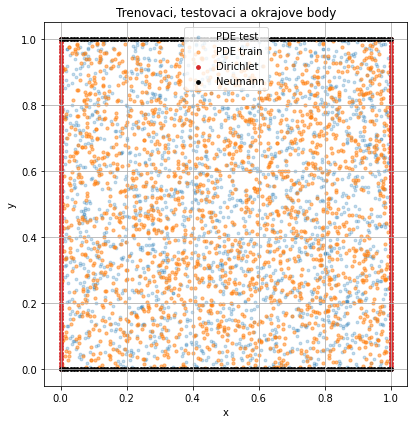

In [17]:
plot_points()


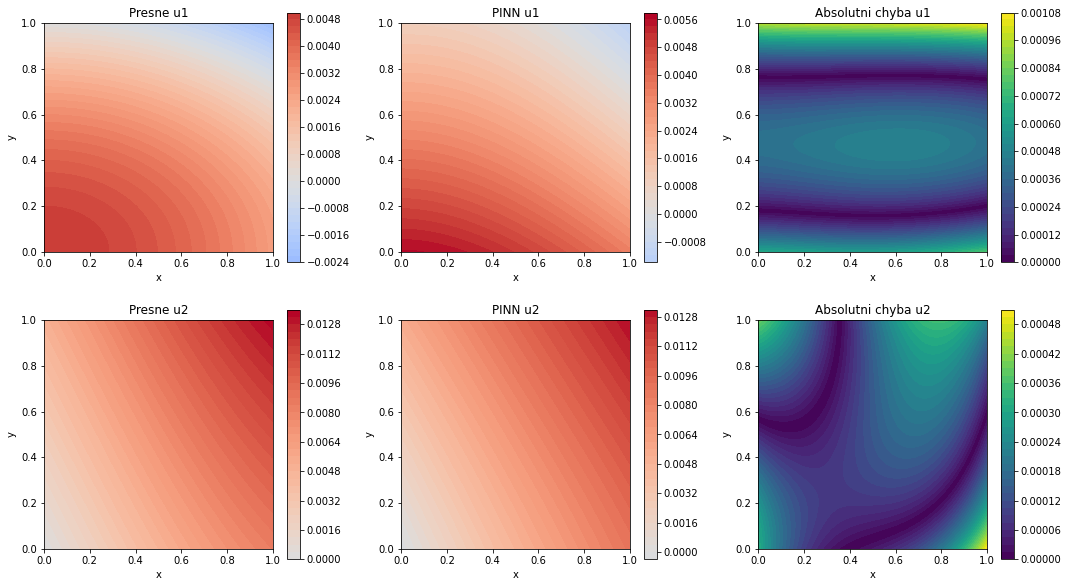

In [18]:
plot_displacement()


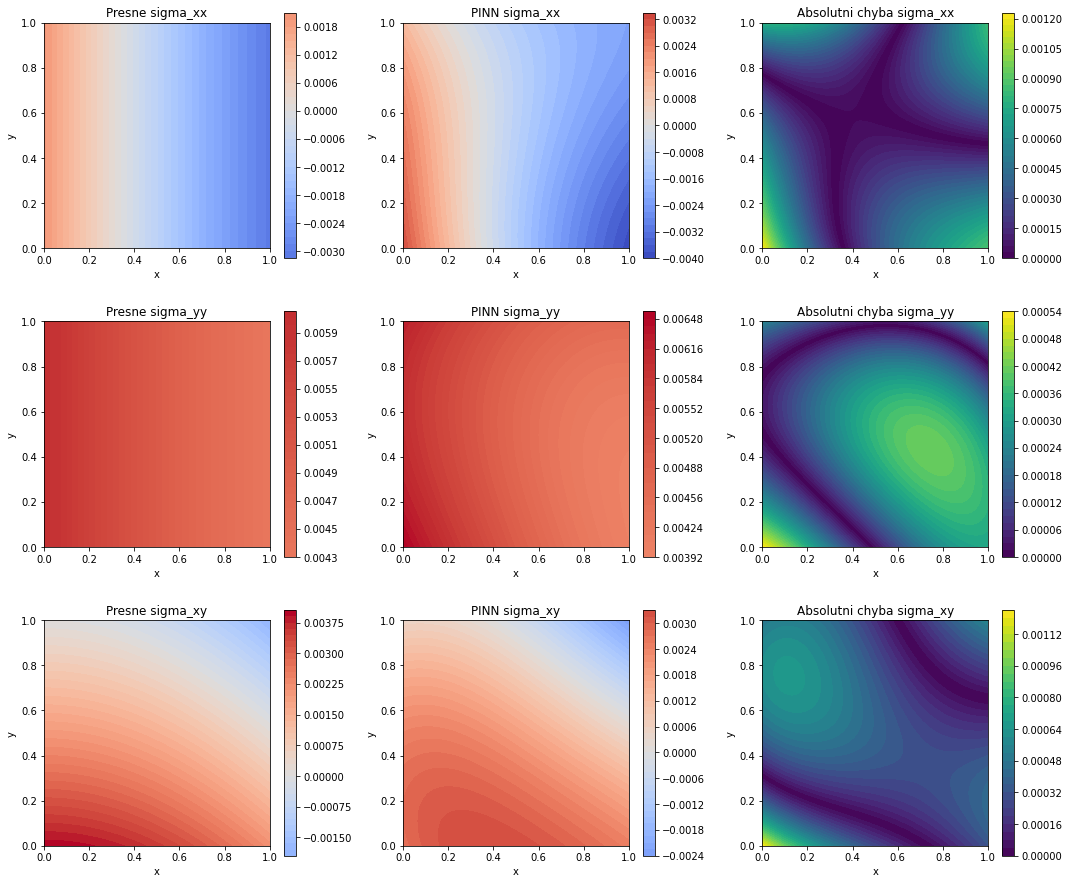

In [19]:
plot_stress()


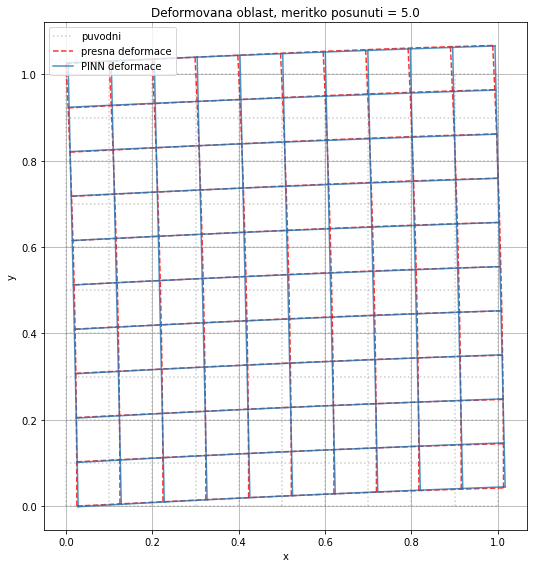

In [20]:
plot_deformed_domain(scale=5.0)


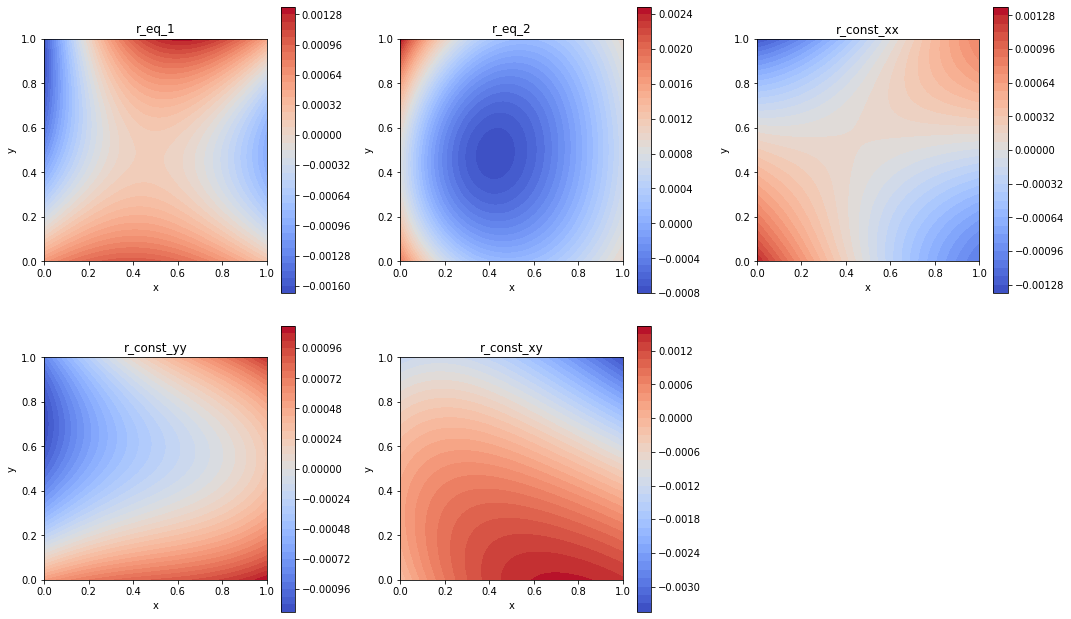

In [21]:
plot_residuals()


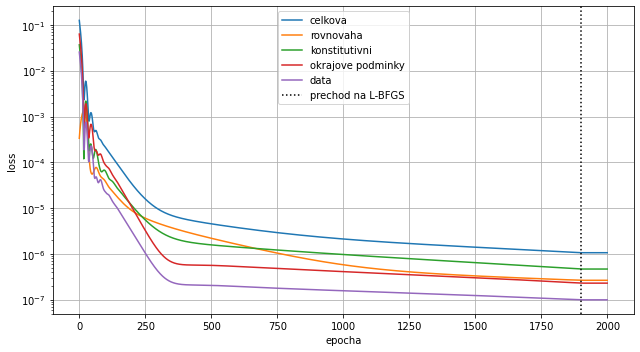

In [22]:
plot_loss()
